# Authors and Works per Decade

Decade-level bar charts of Perseus Greek literature (one row per selected English translation), with polity periods from `humans_clean.sqlite3` overlaid.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

INPUT_TSV = Path('../data/perseus_works_wikidata.tsv')
DB_PATH = '/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/data/humans_clean.sqlite3'

In [2]:
df = pd.read_csv(INPUT_TSV, sep='\t')
df = df[df['selected_english_translation'] == 1].copy()
df['year'] = pd.to_numeric(df['author_impact_date'], errors='coerce')
df = df[df['year'].notna()].copy()
df['year'] = df['year'].astype(int)
df['decade'] = (df['year'] // 10) * 10
print(f'Works with valid decade: {len(df)}')
print(f'Unique authors: {df["perseus_author"].nunique()}')

Works with valid decade: 570
Unique authors: 50


In [3]:
POLITY_NAMES = (
    'Roman Empire', 'Second Athenian League', 'Kingdom of Osroene',
    'Peloponnesian League', 'Greek City-States', 'Delian League',
    'Macedonian Empire', 'Achaean League', 'Cyrenaica', 'Thebans',
    'Roman Republic', 'Ptolemaic Kingdom',
)

with sqlite3.connect(DB_PATH) as conn:
    placeholders = ','.join(['?'] * len(POLITY_NAMES))
    polity_periods = pd.read_sql_query(
        f'''
        SELECT polity_name,
               MIN(from_year) AS start_year,
               MAX(to_year)   AS end_year
        FROM cliopatria_polity_periods
        WHERE polity_name IN ({placeholders})
        GROUP BY polity_name
        ORDER BY start_year
        ''',
        conn,
        params=POLITY_NAMES,
    )
polity_periods

,polity_name,start_year,end_year
0,Greek City-States,-800,83
1,Macedonian Empire,-675,-292
2,Peloponnesian League,-550,-338
3,Roman Republic,-500,-32
4,Second Athenian League,-366,-338
5,Thebans,-350,-338
6,Cyrenaica,-331,-92
7,Ptolemaic Kingdom,-331,-28
8,Achaean League,-279,-145
9,Kingdom of Osroene,-63,214


In [4]:
def add_polity_labels(ax, polity_periods, y_max):
    """Overlay polity names + horizontal arrows, stacked to avoid overlap."""
    periods = polity_periods.sort_values('start_year').to_dict('records')
    levels, period_levels = [], []
    for p in periods:
        start, end = p['start_year'], p['end_year']
        placed = False
        for idx, ranges in enumerate(levels):
            if all(end < rs - 80 or start > re + 80 for rs, re in ranges):
                ranges.append((start, end))
                period_levels.append(idx)
                placed = True
                break
        if not placed:
            levels.append([(start, end)])
            period_levels.append(len(levels) - 1)

    level_spacing = y_max * 0.10
    base_y = y_max * 0.95
    for i, p in enumerate(periods):
        start, end = p['start_year'], p['end_year']
        mid = (start + end) / 2
        y_pos = base_y - period_levels[i] * level_spacing
        ax.text(mid, y_pos, p['polity_name'], ha='center', va='top',
                fontsize=7, fontweight='bold', color='#333333', zorder=5)
        ax.annotate('', xy=(end, y_pos - y_max * 0.035),
                    xytext=(start, y_pos - y_max * 0.035),
                    arrowprops=dict(arrowstyle='<->', color='#555555', lw=1),
                    zorder=5)


def decade_bar(series, ylabel, title, color):
    counts = series.sort_index()
    min_decade, max_decade = int(counts.index.min()), int(counts.index.max())
    xticks = np.arange((min_decade // 50) * 50, max_decade + 50, 50)
    y_max = counts.max() * 1.4

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.bar(counts.index, counts.values, width=8, color=color,
           edgecolor='black', alpha=0.9, zorder=3)
    add_polity_labels(ax, polity_periods, y_max)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, zorder=2)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{abs(int(x))} {"BCE" if x < 0 else "CE"}' for x in xticks],
                       rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=1)
    ax.set_xlim(min_decade - 30, max_decade + 30)
    ax.set_ylim(0, y_max)
    plt.tight_layout()
    plt.show()

## Authors per decade

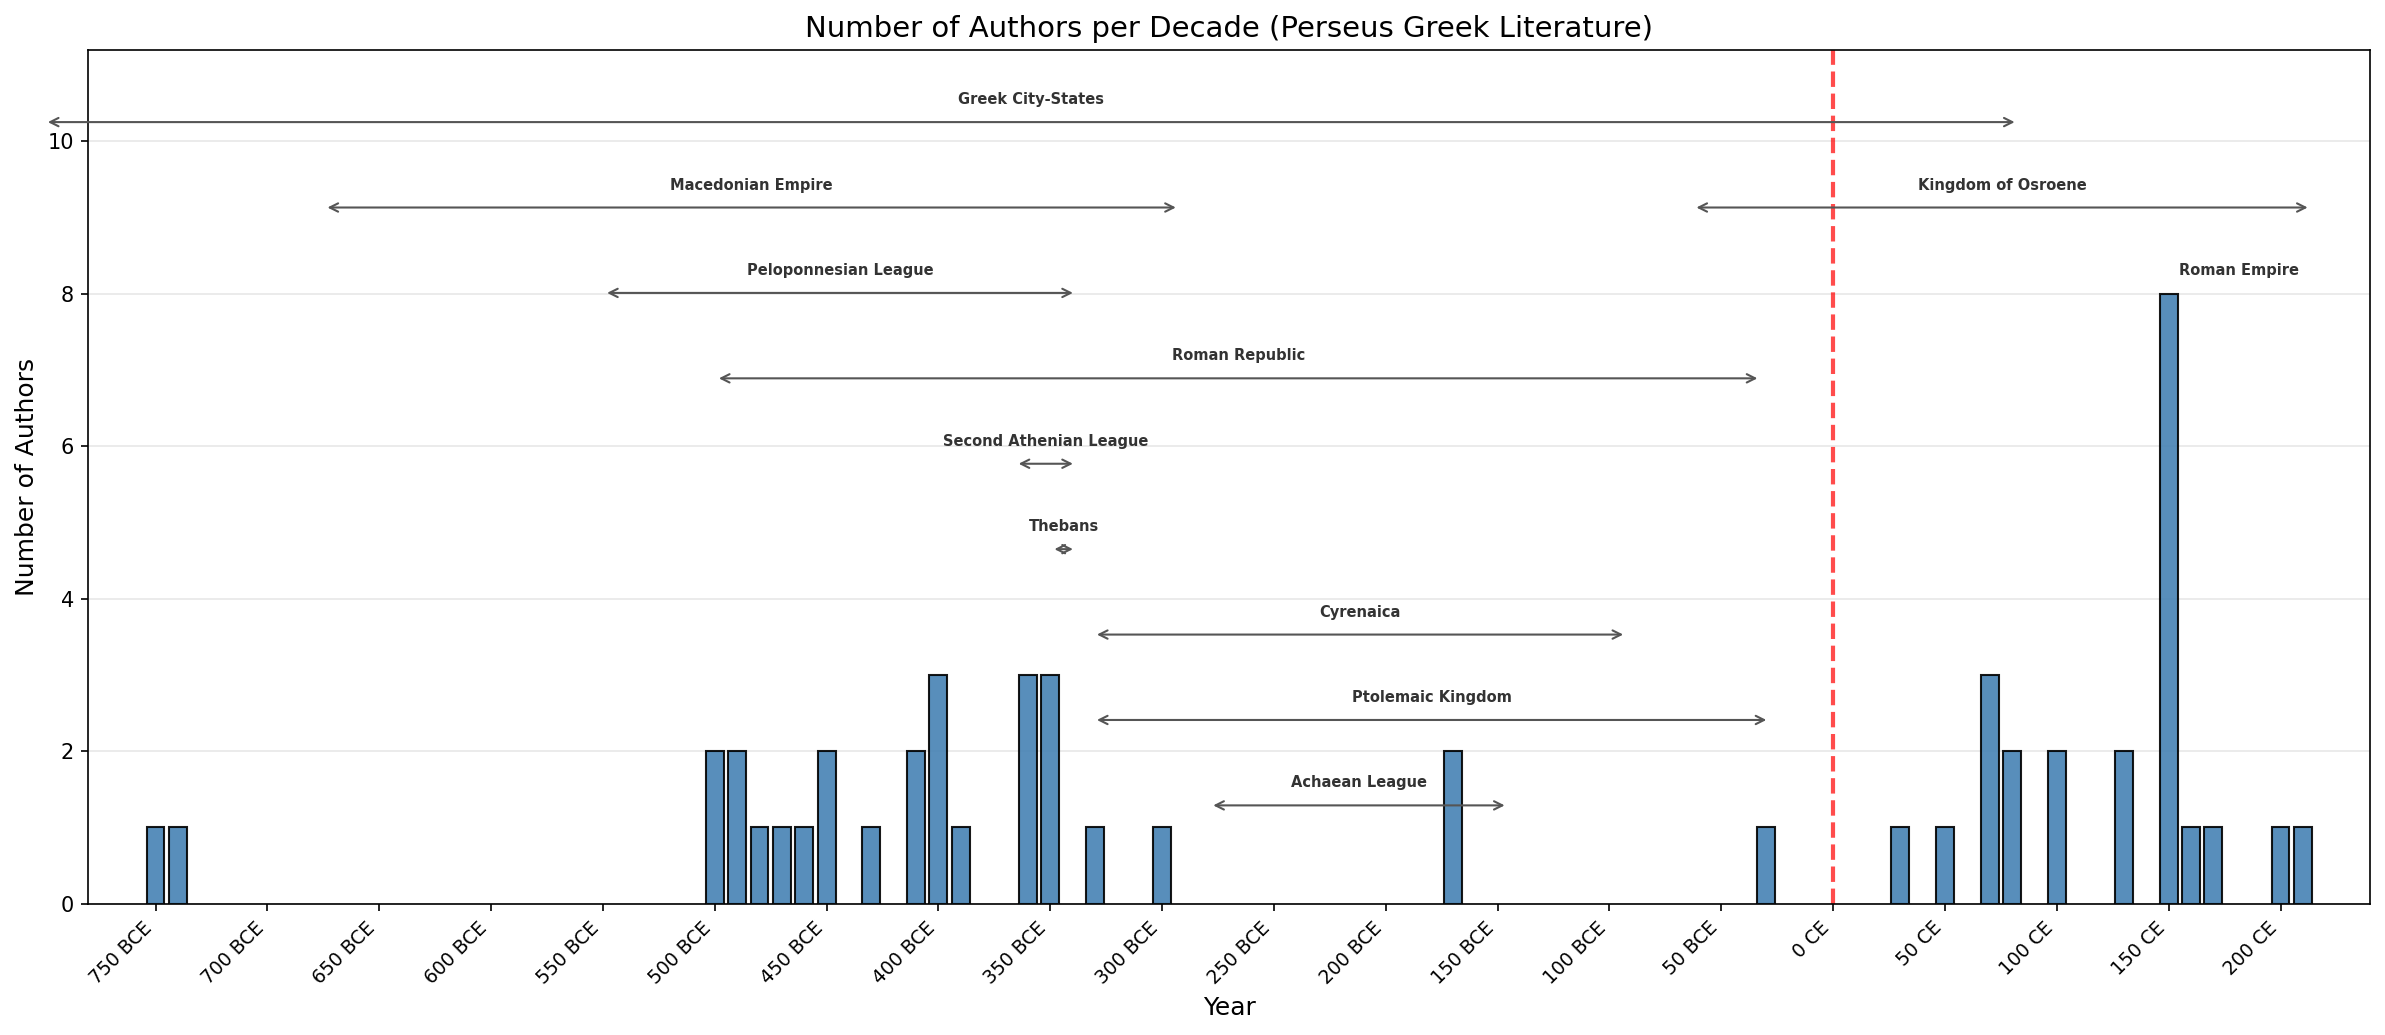

In [5]:
decade_bar(
    df.groupby('decade')['perseus_author'].nunique(),
    ylabel='Number of Authors',
    title='Number of Authors per Decade (Perseus Greek Literature)',
    color='steelblue',
)

## Works per decade

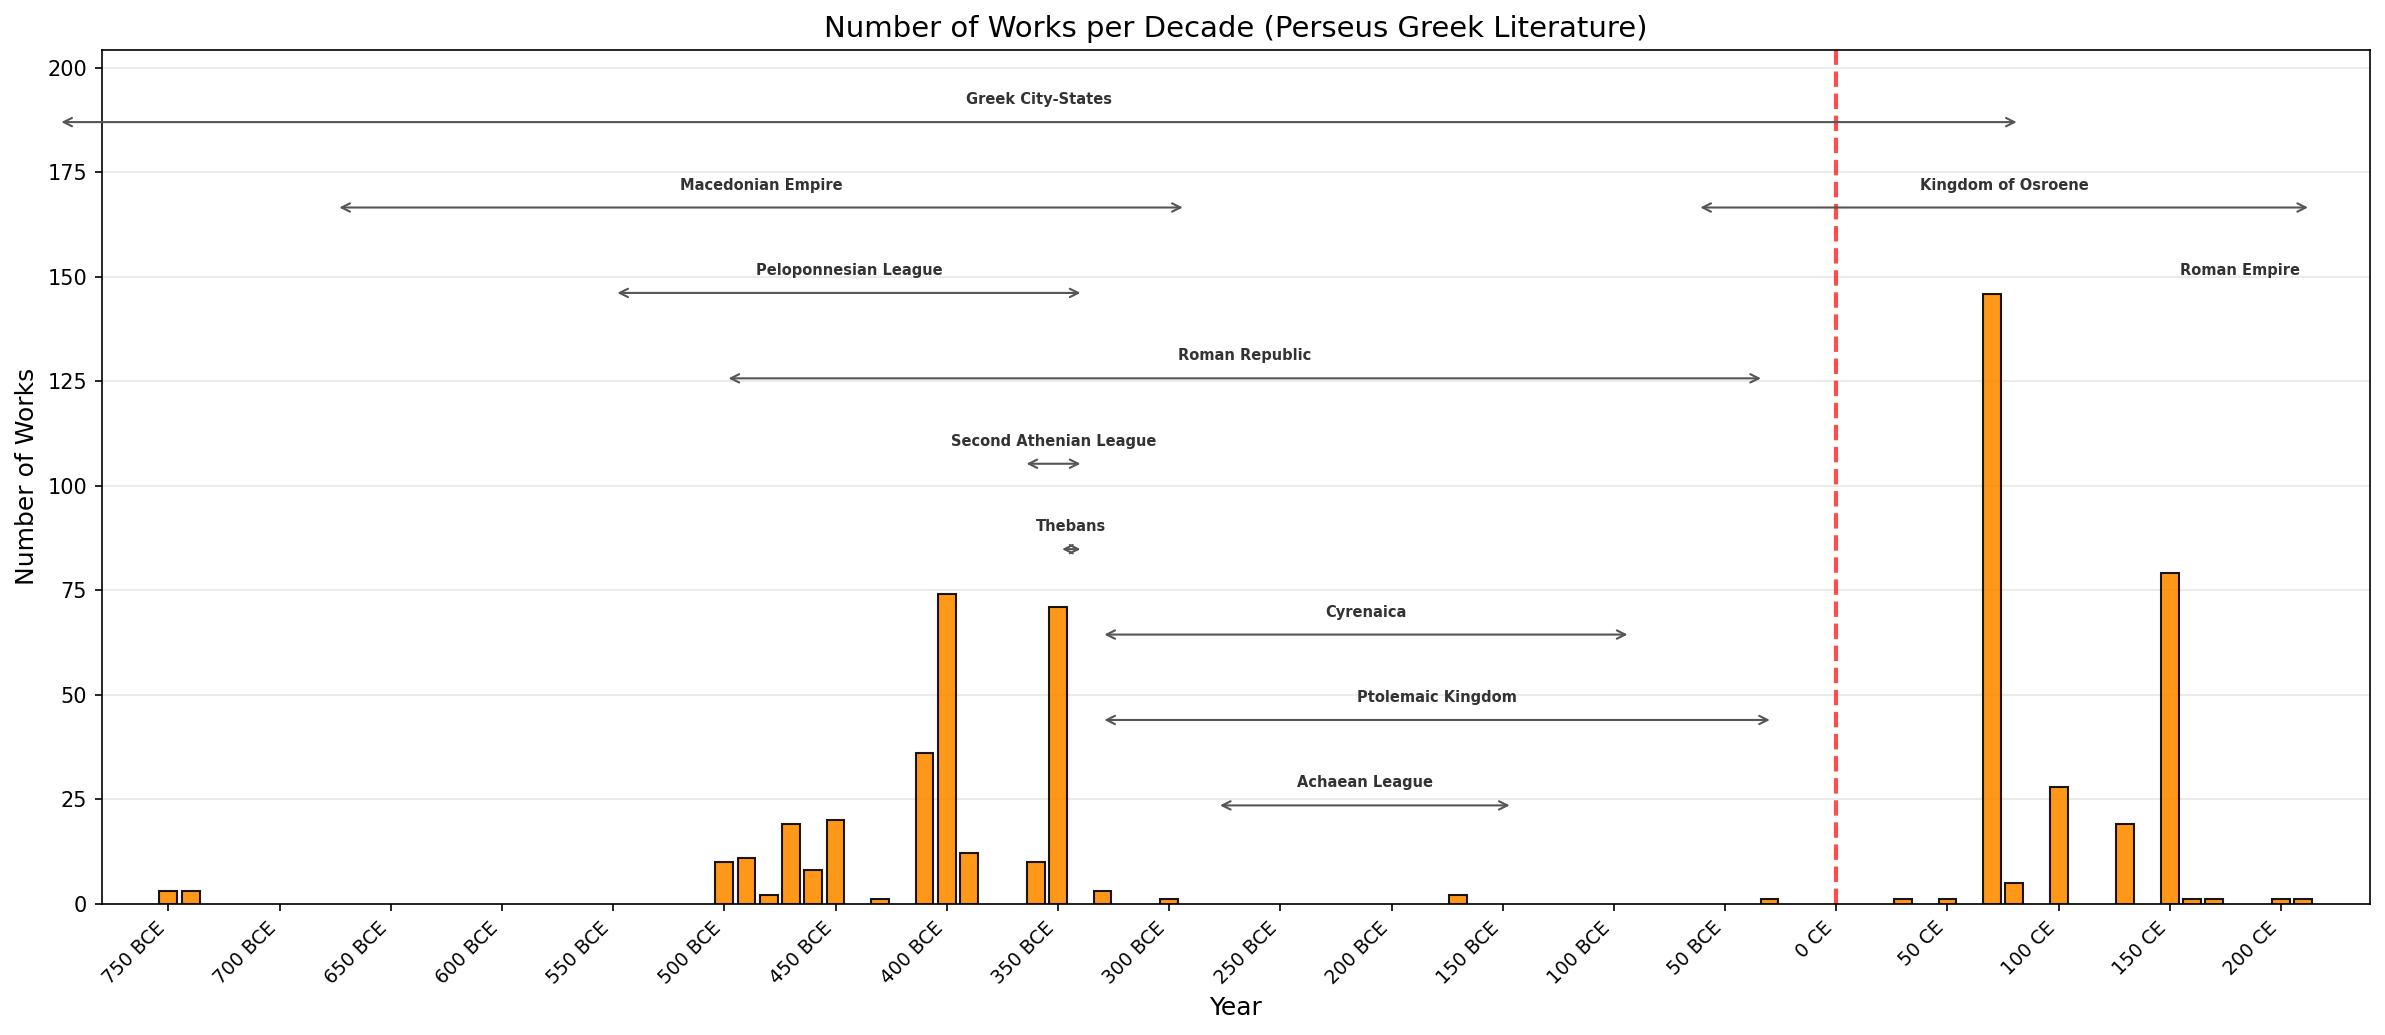

In [6]:
decade_bar(
    df.groupby('decade').size(),
    ylabel='Number of Works',
    title='Number of Works per Decade (Perseus Greek Literature)',
    color='darkorange',
)